In [2]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Configuration des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# #TODO: Charger le jeu de données
# Si le fichier est importé directement dans Colab :
df = pd.read_csv('Churn_Modelling.csv')

# Affichage des 5 premières lignes pour vérification
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Exploration et Nettoyage des Données (EDA)

In [3]:
# #TODO: Explorer la structure des données
print("--- Informations Générales ---")
print(df.info())

print("\n--- Valeurs Manquantes ---")
print(df.isnull().sum())

# Suppression des colonnes d'identification inutiles pour le modèle
df_cleaned = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

--- Informations Générales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

--- Valeurs Manquantes ---
RowNumber          0
CustomerI

Visualisations des facteurs clés de désabonnement
Voici les graphiques qui permettront à la banque de comprendre visuellement le comportement des clients.

/tmp/ipykernel_41992/3357713068.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='Exited', palette='Set2')


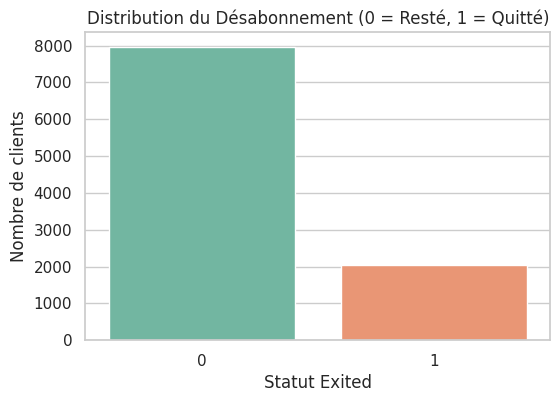

/tmp/ipykernel_41992/3357713068.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='Exited', y='Age', palette='Pastel1')


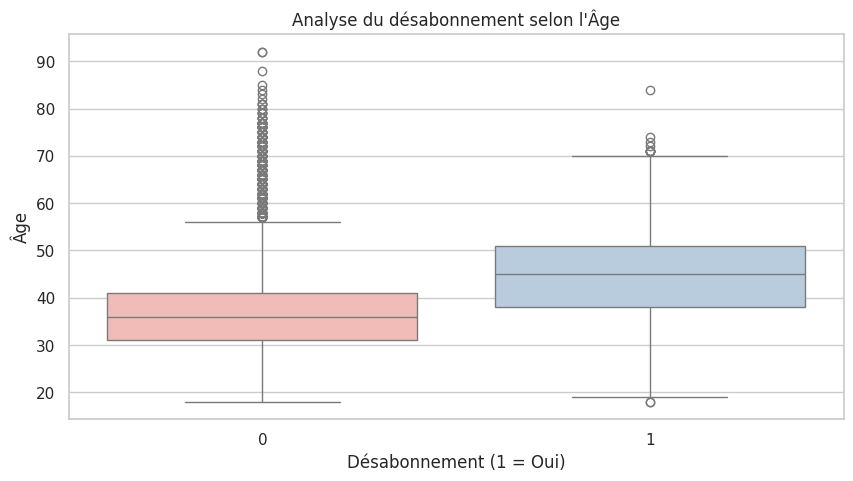

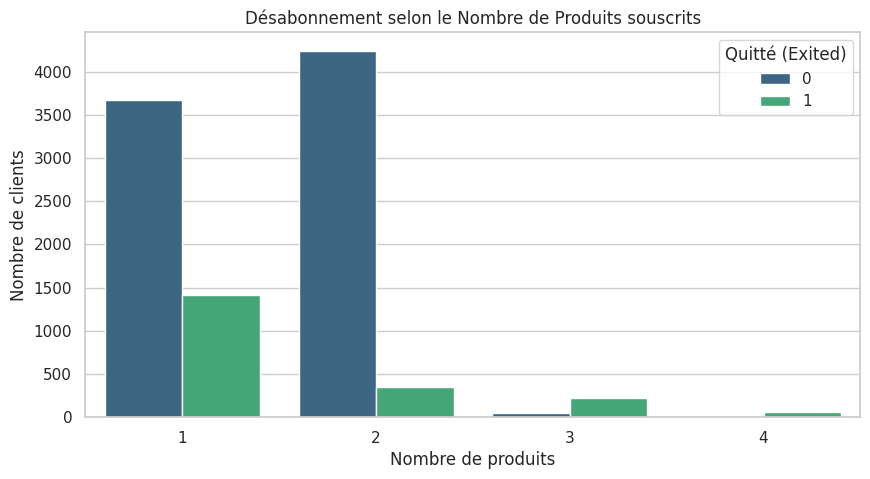

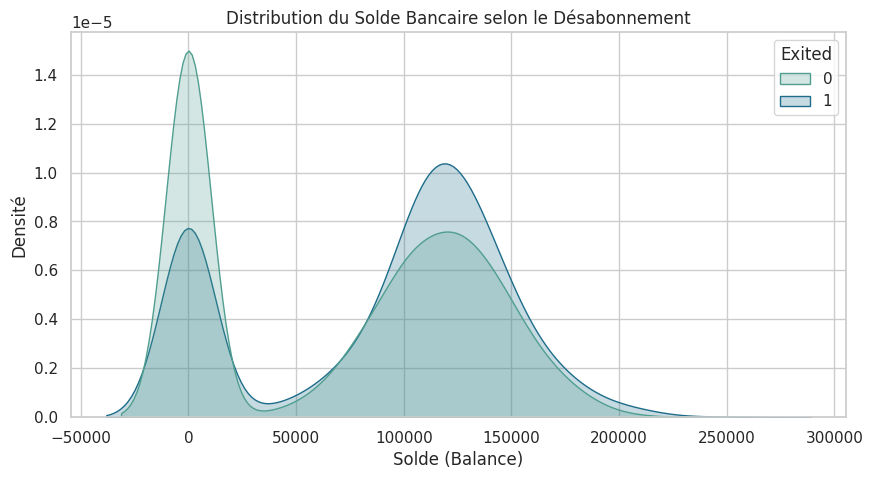

In [4]:
# #TODO: Visualiser la distribution du désabonnement (Exited)
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cleaned, x='Exited', palette='Set2')
plt.title('Distribution du Désabonnement (0 = Resté, 1 = Quitté)')
plt.xlabel('Statut Exited')
plt.ylabel('Nombre de clients')
plt.show()

# 1. Impact de l'Âge sur le désabonnement
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_cleaned, x='Exited', y='Age', palette='Pastel1')
plt.title("Analyse du désabonnement selon l'Âge")
plt.xlabel('Désabonnement (1 = Oui)')
plt.ylabel('Âge')
plt.show()

# 2. Impact du Nombre de Produits
plt.figure(figsize=(10, 5))
sns.countplot(data=df_cleaned, x='NumOfProducts', hue='Exited', palette='viridis')
plt.title('Désabonnement selon le Nombre de Produits souscrits')
plt.xlabel('Nombre de produits')
plt.ylabel('Nombre de clients')
plt.legend(title='Quitté (Exited)', loc='upper right')
plt.show()

# 3. Impact du Solde du compte (Balance)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_cleaned, x='Balance', hue='Exited', fill=True, common_norm=False, palette='crest')
plt.title('Distribution du Solde Bancaire selon le Désabonnement')
plt.xlabel('Solde (Balance)')
plt.ylabel('Densité')
plt.show()

3. Préparation des Données (Preprocessing)

In [5]:
# #TODO: Séparer les features (X) et la cible (y)
X = df_cleaned.drop(columns=['Exited'])
y = df_cleaned['Exited']

# Identification des colonnes par type
categorical_cols = ['Geography', 'Gender']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Création du transformateur pour standardiser le numérique et encoder le catégoriel
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols) # drop='first' évite la colinéarité
    ])

# Division en ensembles d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Application des transformations
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Récupération des noms de colonnes après transformation (utile pour l'importance des variables)
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + encoded_cat_cols

4. Entraînement du Modèle Prédictif

In [6]:
# #TODO: Initialiser et entraîner le modèle
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_transformed, y_train)

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test_transformed)
y_prob = model.predict_proba(X_test_transformed)[:, 1]

5. Évaluation du Modèle et Informations Commerciales

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000

Score AUC-ROC : 0.8508


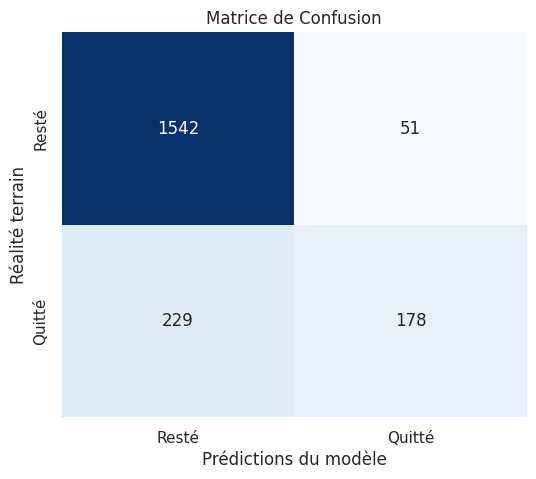

In [7]:
# #TODO: Évaluer les performances
print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))

print(f"Score AUC-ROC : {roc_auc_score(y_test, y_prob):.4f}")

# Matrice de confusion visuelle
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Resté', 'Quitté'], yticklabels=['Resté', 'Quitté'])
plt.title('Matrice de Confusion')
plt.xlabel('Prédictions du modèle')
plt.ylabel('Réalité terrain')
plt.show()

Extraction des insights commerciaux (Importance des variables)

/tmp/ipykernel_41992/124881607.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[all_features[i] for i in indices], palette='viridis')


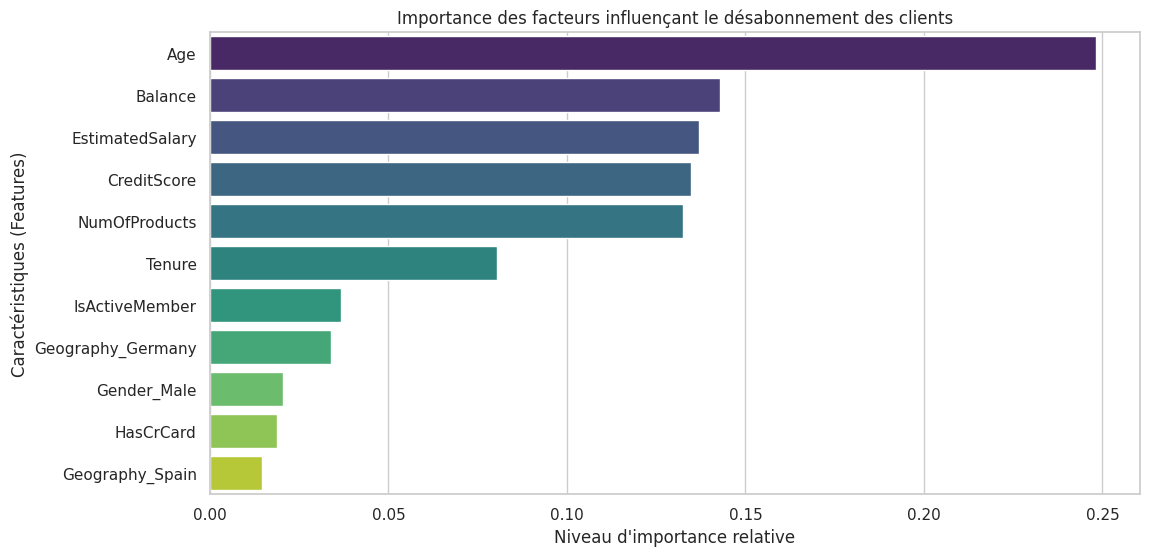

In [8]:
# #TODO: Extraire et afficher l'importance des fonctionnalités
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=[all_features[i] for i in indices], palette='viridis')
plt.title('Importance des facteurs influençant le désabonnement des clients')
plt.xlabel('Niveau d\'importance relative')
plt.ylabel('Caractéristiques (Features)')
plt.show()

6. Synthèse des Recommandations Commerciales Pour votre conclusion
 Analyse des Résultats & Actions à mener par la Banque :

L'Âge est le facteur principal : Les graphiques et le modèle montrent que les clients plus âgés ont une propension nettement plus forte à quitter l'établissement. La banque doit concevoir des offres de fidélisation ou des services patrimoniaux spécifiquement adaptés aux séniors 40-60 ans.

Le Nombre de Produits : Les clients possédant 3 ou 4 produits affichent paradoxalement un taux de désabonnement critique. Cela peut traduire une insatisfaction liée à des frais cumulés ou une mauvaise expérience produit. Une politique de simplification des offres est recommandée.

Le Solde du compte Balance : Les profils avec des soldes importants quittent également la banque. Il est crucial pour les conseillers clientèle d'appeler proactivement les clients à capitaux élevés dès qu'une baisse d'activité transactionnelle est détectée.